#  Temporal & Outcome Analysis

## Objective

Analyze temporal patterns in UAC care activity to identify changes in transfer, discharge, and operational pressure across months, years, and reporting days.

## Business Questions

- How do transfer and discharge activities change over time?
- Are there meaningful month-to-month patterns?
- How does operational activity differ across years?
- Are certain reporting days associated with higher or lower activity?
- Are outcome measures becoming more or less stable over time?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/uac_eda.csv")

df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.strftime("%B")
df["day_of_week"] = df["date"].dt.day_name()

df.head()

,date,apprehended,cbp_custody,transferred,hhs_care,discharged,month,year,cbp_net_pressure,hhs_net_pressure,day_of_week,month_name
0,2023-01-12,33.0,53.0,34.0,6566,436.0,1,2023,-1.0,-402.0,Thursday,January
1,2023-01-22,32.0,49.0,39.0,7122,227.0,1,2023,-7.0,-188.0,Sunday,January
2,2023-01-23,32.0,50.0,39.0,7280,181.0,1,2023,-7.0,-142.0,Monday,January
3,2023-01-24,47.0,42.0,47.0,7433,175.0,1,2023,0.0,-128.0,Tuesday,January
4,2023-01-25,20.0,22.0,41.0,7538,180.0,1,2023,-21.0,-139.0,Wednesday,January


## 7.1 Monthly Transfer and Discharge Activity

### Business Question

How does transfer and discharge activity change from month to month?

### Description

Monthly aggregation is used to identify broader seasonal and operational patterns in transfers out of CBP custody and discharges from HHS care.

Monthly totals are calculated from the reporting observations available in the dataset.

In [2]:
monthly_activity = (
    df.groupby(["year", "month"])
    .agg(
        transferred=("transferred", "sum"),
        discharged=("discharged", "sum")
    )
    .reset_index()
)

monthly_activity["period"] = pd.to_datetime(
    monthly_activity["year"].astype(str)
    + "-"
    + monthly_activity["month"].astype(str)
    + "-01"
)

monthly_activity.head()

,year,month,transferred,discharged,period
0,2023,1,276.0,1856.0,2023-01-01
1,2023,2,2637.0,5183.0,2023-02-01
2,2023,3,3399.0,5375.0,2023-03-01
3,2023,4,3967.0,5668.0,2023-04-01
4,2023,5,3622.0,6256.0,2023-05-01


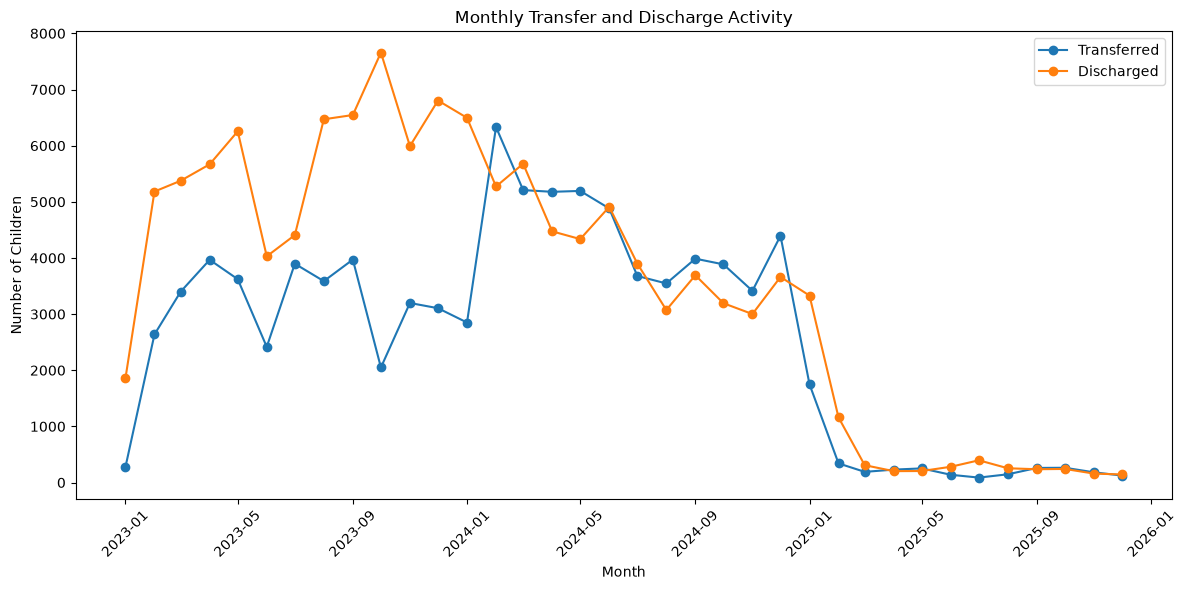

In [3]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_activity["period"],
    monthly_activity["transferred"],
    marker="o",
    label="Transferred"
)

plt.plot(
    monthly_activity["period"],
    monthly_activity["discharged"],
    marker="o",
    label="Discharged"
)

plt.title("Monthly Transfer and Discharge Activity")
plt.xlabel("Month")
plt.ylabel("Number of Children")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Figure 1: Monthly Transfer and Discharge Activity

### Key Finding

Transfer and discharge activity changes across months, indicating variation in the volume of children moving through the care pipeline.

### Business Implication

Monthly monitoring can help identify periods of increased operational activity and support resource planning.

## 7.2 Year-over-Year Activity Analysis

### Business Question

How has overall UAC pipeline activity changed across years?

### Description

Yearly totals are compared across major pipeline flow variables to identify changes in overall operational activity.

The analysis focuses on recorded activity rather than interpreting changes as direct changes in individual outcomes.

In [4]:
yearly_activity = (
    df.groupby("year")
    .agg(
        apprehended=("apprehended", "sum"),
        transferred=("transferred", "sum"),
        discharged=("discharged", "sum")
    )
)

yearly_activity

,apprehended,transferred,discharged
year,,,
2023,27056.0,36124.0,66244.0
2024,37166.0,52552.0,51689.0
2025,3115.0,3965.0,6920.0


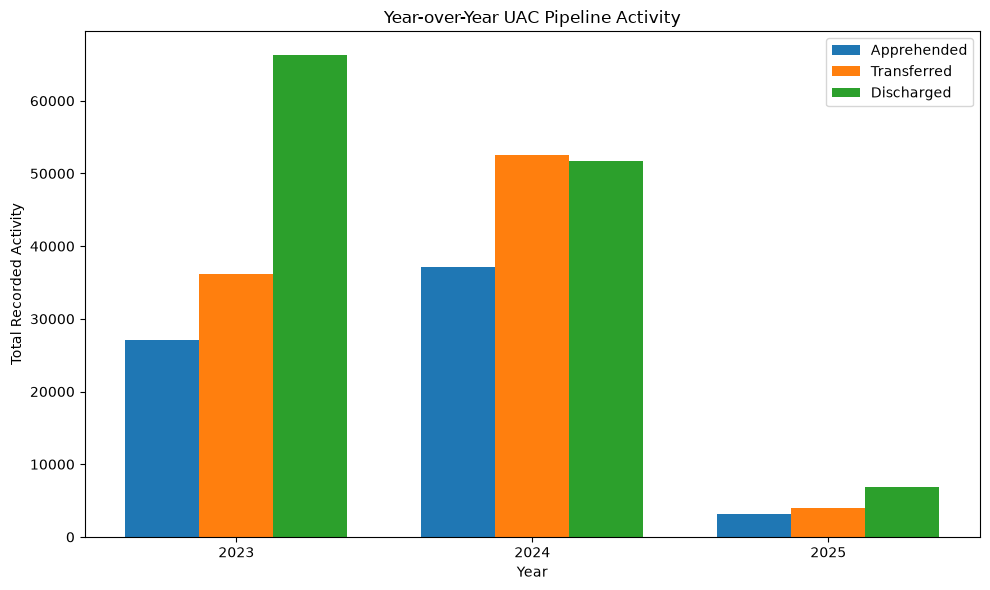

In [5]:
plt.figure(figsize=(10, 6))

x = np.arange(len(yearly_activity.index))
width = 0.25

plt.bar(
    x - width,
    yearly_activity["apprehended"],
    width,
    label="Apprehended"
)

plt.bar(
    x,
    yearly_activity["transferred"],
    width,
    label="Transferred"
)

plt.bar(
    x + width,
    yearly_activity["discharged"],
    width,
    label="Discharged"
)

plt.title("Year-over-Year UAC Pipeline Activity")
plt.xlabel("Year")
plt.ylabel("Total Recorded Activity")
plt.xticks(x, yearly_activity.index)
plt.legend()

plt.tight_layout()
plt.show()

### Figure 2: Year-over-Year UAC Pipeline Activity

### Key Finding

Annual activity levels differ across the observation period, showing changes in the volume of recorded apprehensions, transfers, and discharges.

### Business Implication

Yearly comparisons provide stakeholders with a high-level view of how pipeline activity changes over longer periods.

## 7.3 Year-over-Year Percentage Change

### Business Question

How large are the changes in pipeline activity between consecutive years?

### Description

Year-over-year percentage change measures the relative increase or decrease in annual apprehension, transfer, and discharge activity.

This provides a normalized comparison when annual activity levels differ substantially.

In [6]:
yoy_change = yearly_activity.pct_change() * 100

yoy_change

,apprehended,transferred,discharged
year,,,
2023,NaN,NaN,NaN
2024,37.366943,45.476691,-21.971801
2025,-91.618684,-92.455092,-86.612239


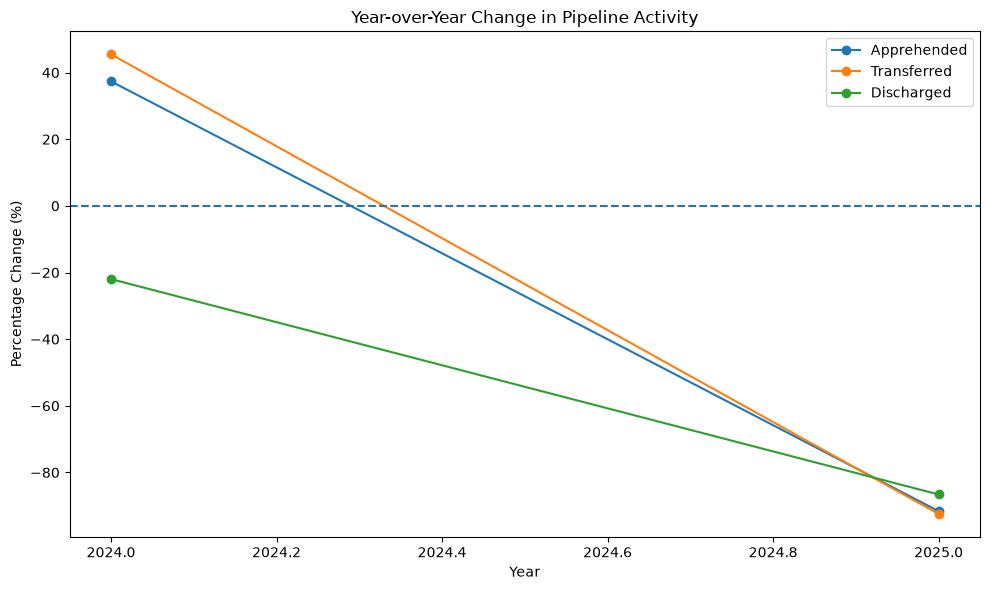

In [7]:
plt.figure(figsize=(10, 6))

plt.plot(
    yoy_change.index,
    yoy_change["apprehended"],
    marker="o",
    label="Apprehended"
)

plt.plot(
    yoy_change.index,
    yoy_change["transferred"],
    marker="o",
    label="Transferred"
)

plt.plot(
    yoy_change.index,
    yoy_change["discharged"],
    marker="o",
    label="Discharged"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Year-over-Year Change in Pipeline Activity")
plt.xlabel("Year")
plt.ylabel("Percentage Change (%)")
plt.legend()

plt.tight_layout()
plt.show()

### Figure 3: Year-over-Year Change in Pipeline Activity

### Key Finding

The year-over-year analysis highlights periods of relative growth or decline in recorded pipeline activity.

### Business Implication

Large changes between years can help identify periods that require additional contextual or operational investigation.

## 7.4 Day-of-Week Activity

### Business Question

Does recorded pipeline activity vary by reporting day?

### Description

Average apprehension, transfer, and discharge activity is compared across days of the week.

Because the dataset does not contain observations for every calendar day, these results represent reporting-day patterns rather than complete daily operational patterns.

In [8]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_activity = (
    df.groupby("day_of_week")
    .agg(
        apprehended=("apprehended", "mean"),
        transferred=("transferred", "mean"),
        discharged=("discharged", "mean")
    )
    .reindex(weekday_order)
)

weekday_activity

,apprehended,transferred,discharged
day_of_week,,,
Monday,93.779310,123.731034,157.558621
Tuesday,97.114094,124.859060,136.114094
Wednesday,93.802721,131.673469,166.013605
Thursday,94.693878,133.414966,205.687075
Friday,44.500000,110.000000,144.000000
Saturday,NaN,NaN,NaN
Sunday,88.238462,130.061538,206.138462


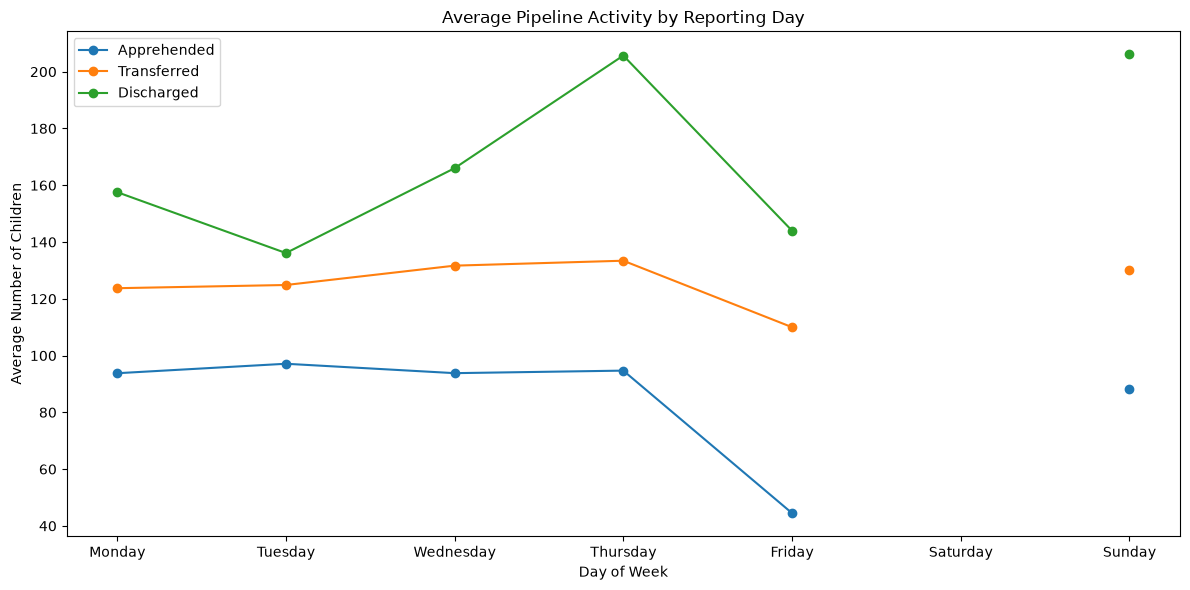

In [9]:
plt.figure(figsize=(12, 6))

plt.plot(
    weekday_activity.index,
    weekday_activity["apprehended"],
    marker="o",
    label="Apprehended"
)

plt.plot(
    weekday_activity.index,
    weekday_activity["transferred"],
    marker="o",
    label="Transferred"
)

plt.plot(
    weekday_activity.index,
    weekday_activity["discharged"],
    marker="o",
    label="Discharged"
)

plt.title("Average Pipeline Activity by Reporting Day")
plt.xlabel("Day of Week")
plt.ylabel("Average Number of Children")
plt.legend()

plt.tight_layout()
plt.show()

### Figure 4: Average Pipeline Activity by Reporting Day

### Key Finding

Average pipeline activity differs across reporting days, although the number of observations is not evenly distributed across all weekdays.

### Business Implication

Day-of-week patterns can help identify differences in reported operational activity, but should be interpreted alongside reporting frequency and coverage.

## 7.5 Monthly Operational Pressure

### Business Question

Which months show higher levels of operational pressure?

### Description

Monthly CBP and HHS net pressure are calculated to identify periods where incoming activity exceeded outgoing activity at each stage of the pipeline.

In [10]:
df["cbp_net_pressure"] = (
    df["apprehended"] -
    df["transferred"]
)

df["hhs_net_pressure"] = (
    df["transferred"] -
    df["discharged"]
)

monthly_pressure = (
    df.groupby(["year", "month"])
    .agg(
        cbp_pressure=("cbp_net_pressure", "mean"),
        hhs_pressure=("hhs_net_pressure", "mean")
    )
    .reset_index()
)

monthly_pressure["period"] = pd.to_datetime(
    monthly_pressure["year"].astype(str)
    + "-"
    + monthly_pressure["month"].astype(str)
    + "-01"
)

monthly_pressure.head()

,year,month,cbp_pressure,hhs_pressure,period
0,2023,1,-3.625000,-197.500000,2023-01-01
1,2023,2,-39.526316,-134.000000,2023-02-01
2,2023,3,-48.421053,-104.000000,2023-03-01
3,2023,4,-39.904762,-81.000000,2023-04-01
4,2023,5,-39.818182,-119.727273,2023-05-01


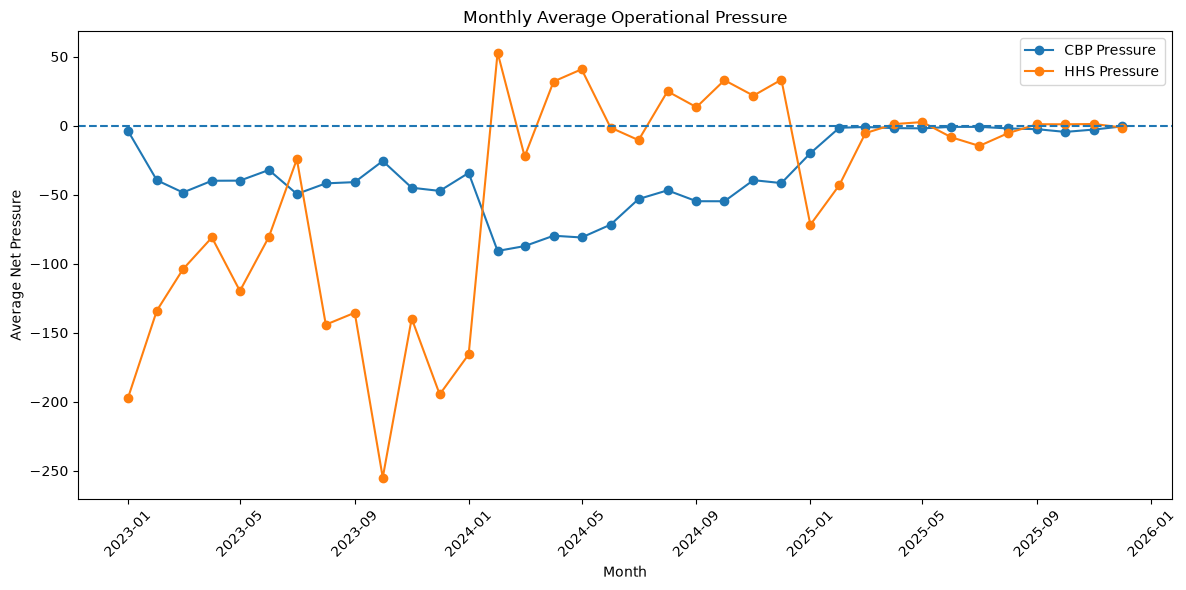

In [11]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_pressure["period"],
    monthly_pressure["cbp_pressure"],
    marker="o",
    label="CBP Pressure"
)

plt.plot(
    monthly_pressure["period"],
    monthly_pressure["hhs_pressure"],
    marker="o",
    label="HHS Pressure"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Monthly Average Operational Pressure")
plt.xlabel("Month")
plt.ylabel("Average Net Pressure")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Figure 5: Monthly Average Operational Pressure

### Key Finding

Operational pressure changes across months at both the CBP and HHS stages.

### Business Implication

Monthly pressure patterns can help identify periods where incoming activity was relatively high compared with outgoing activity.

## 7.6 Outcome Stability by Year

### Business Question

Does the consistency of transfer and discharge efficiency change over time?

### Description

The coefficient of variation is calculated separately for each year to evaluate changes in the relative variability of transfer efficiency and discharge effectiveness.

In [12]:
df["transfer_efficiency"] = np.where(
    df["cbp_custody"] > 0,
    df["transferred"] / df["cbp_custody"],
    np.nan
)

df["discharge_effectiveness"] = np.where(
    df["hhs_care"] > 0,
    df["discharged"] / df["hhs_care"],
    np.nan
)

yearly_stability = (
    df.groupby("year")
    .agg(
        transfer_mean=("transfer_efficiency", "mean"),
        transfer_std=("transfer_efficiency", "std"),
        discharge_mean=("discharge_effectiveness", "mean"),
        discharge_std=("discharge_effectiveness", "std")
    )
)

yearly_stability["transfer_cv"] = (
    yearly_stability["transfer_std"] /
    yearly_stability["transfer_mean"]
)

yearly_stability["discharge_cv"] = (
    yearly_stability["discharge_std"] /
    yearly_stability["discharge_mean"]
)

yearly_stability

,transfer_mean,transfer_std,discharge_mean,discharge_std,transfer_cv,discharge_cv
year,,,,,,
2023,0.829958,0.250131,0.033358,0.007443,0.301378,0.223127
2024,0.783356,0.197894,0.028968,0.007195,0.252624,0.248391
2025,0.460335,0.327938,0.008985,0.009521,0.712390,1.059674


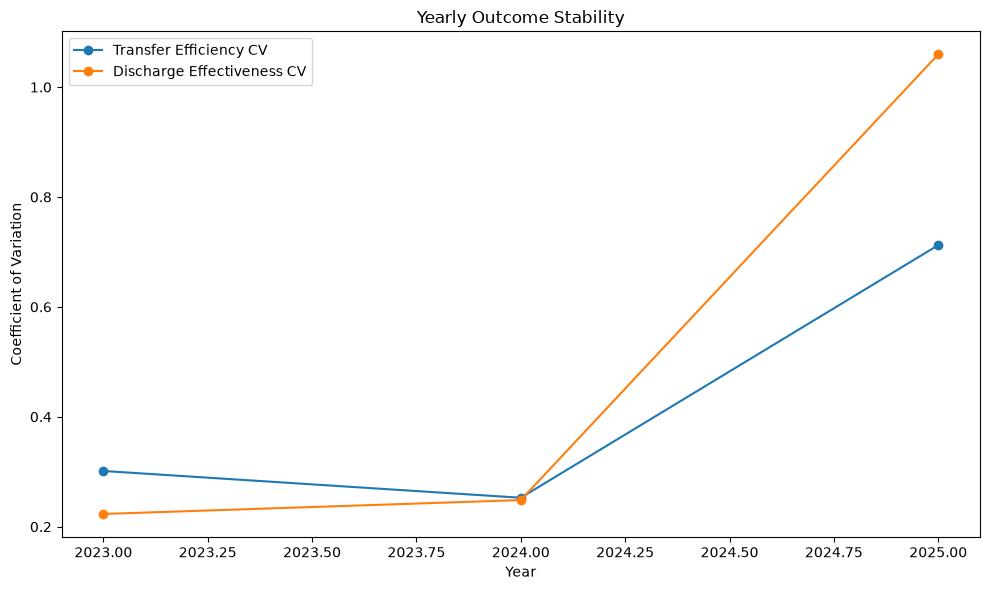

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(
    yearly_stability.index,
    yearly_stability["transfer_cv"],
    marker="o",
    label="Transfer Efficiency CV"
)

plt.plot(
    yearly_stability.index,
    yearly_stability["discharge_cv"],
    marker="o",
    label="Discharge Effectiveness CV"
)

plt.title("Yearly Outcome Stability")
plt.xlabel("Year")
plt.ylabel("Coefficient of Variation")
plt.legend()

plt.tight_layout()
plt.show()

### Figure 6: Yearly Outcome Stability

### Key Finding

The coefficient of variation changes across years, indicating that the relative consistency of transfer efficiency and discharge effectiveness is not constant.

### Business Implication

Changes in outcome stability can help identify years where operational performance showed greater variability and may require additional investigation.

## 7.7 Temporal KPI Summary

### Business Question

What are the main temporal indicators identified during the analysis?

### Description

The temporal KPI summary consolidates annual activity, pressure, and efficiency measures into a single analytical view.

In [14]:
temporal_kpis = pd.DataFrame({
    "KPI": [
        "Total Apprehensions",
        "Total Transfers",
        "Total Discharges",
        "Average CBP Pressure",
        "Average HHS Pressure",
        "Average Transfer Efficiency",
        "Average Discharge Effectiveness"
    ],
    "Value": [
        df["apprehended"].sum(),
        df["transferred"].sum(),
        df["discharged"].sum(),
        df["cbp_net_pressure"].mean(),
        df["hhs_net_pressure"].mean(),
        df["transfer_efficiency"].mean(),
        df["discharge_effectiveness"].mean()
    ]
})

temporal_kpis

,KPI,Value
0,Total Apprehensions,67337.000000
1,Total Transfers,92641.000000
2,Total Discharges,124853.000000
3,Average CBP Pressure,-35.144444
4,Average HHS Pressure,-44.738889
5,Average Transfer Efficiency,0.691018
6,Average Discharge Effectiveness,0.023737


## Executive Summary

### Key Findings

- Monthly transfer and discharge activity varies across the observation period.
- Year-over-year analysis shows changes in the overall volume of recorded pipeline activity.
- Percentage-change analysis highlights periods of relative growth or decline.
- Reporting-day analysis reveals differences in average activity, although reporting coverage is uneven.
- Monthly pressure analysis identifies periods of relatively higher operational pressure.
- Yearly stability analysis shows how the consistency of efficiency measures changes over time.

### Conclusion

This analysis adds a temporal perspective to the UAC care pipeline analysis.

The analysis identifies when operational activity, pressure, and efficiency measures change across the observation period. These findings complement the efficiency and bottleneck measures developed in earlier phases.

Together, the temporal indicators can support dashboard trend analysis and help stakeholders focus attention on periods showing notable changes in operational activity or pressure.